# ART Attack Types and Scoring Contexts

This notebook showcases ART attack families and subtypes without defenses.

The organizing rule is simple: each family is shown in its own scoring context.

- Evasion compares `benign_*` against `evasion_*`.
- Membership inference uses `membership_inference_*`.
- Attribute inference uses `inferred_<attribute>_*`.
- Additional families are catalogued separately so we do not mix incompatible metrics in one chart.

The implemented sections in this first pass are:

- sklearn logistic regression with several evasion subtypes
- torch `TinyNet` with several evasion subtypes
- membership inference on tabular data
- attribute inference on tabular data

In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import torch
import torch.nn as nn

from deckard.attack import AttackConfig, PytorchAttackConfig
from deckard.data import DataConfig, PytorchDataConfig
from deckard.model import ModelConfig, PytorchModelConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

NOTEBOOK_ROOT = Path.cwd()
if NOTEBOOK_ROOT.name != "notebooks":
    NOTEBOOK_ROOT = NOTEBOOK_ROOT / "notebooks"
PROJECT_ROOT = NOTEBOOK_ROOT.parent
EXAMPLES_PYTORCH_DIR = PROJECT_ROOT / "examples" / "pytorch"
if str(EXAMPLES_PYTORCH_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_PYTORCH_DIR))
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "art_attacks_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Artifacts will be written under: {ARTIFACT_DIR}")

/Users/c.meyers/Documents/deckard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts will be written under: /Users/c.meyers/Documents/deckard/notebooks/build/art_attacks_artifacts


In [2]:
attack_catalog = pd.DataFrame(
    [
        {
            "attack_family": "evasion",
            "attack_subtype": "FastGradientMethod",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "evasion",
            "attack_subtype": "HopSkipJump",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "evasion",
            "attack_subtype": "BoundaryAttack",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "membership_inference",
            "attack_subtype": "MembershipInferenceBlackBox",
            "native_score_context": "membership_inference_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "attribute_inference",
            "attack_subtype": "AttributeInferenceBlackBox",
            "native_score_context": "inferred_<attribute>_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "poisoning",
            "attack_subtype": "PoisoningAttackSVM",
            "native_score_context": "benign_* vs poisoned_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "extraction",
            "attack_subtype": "CopycatCNN",
            "native_score_context": "benign_* vs extracted_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "model_inversion",
            "attack_subtype": "MIFace",
            "native_score_context": "model_inversion_*",
            "implementation_status": "catalogued",
        },
        {
            "attack_family": "reconstruction",
            "attack_subtype": "DatabaseReconstruction",
            "native_score_context": "database_reconstruction_*",
            "implementation_status": "catalogued",
        },
    ]
)

display(attack_catalog)

,attack_family,attack_subtype,native_score_context,implementation_status
0,evasion,FastGradientMethod,benign_* vs evasion_*,implemented
1,evasion,HopSkipJump,benign_* vs evasion_*,implemented
2,evasion,BoundaryAttack,benign_* vs evasion_*,implemented
3,membership_inference,MembershipInferenceBlackBox,membership_inference_*,implemented
4,attribute_inference,AttributeInferenceBlackBox,inferred_<attribute>_*,implemented
5,poisoning,PoisoningAttackSVM,benign_* vs poisoned_*,implemented
6,extraction,CopycatCNN,benign_* vs extracted_*,implemented
7,model_inversion,MIFace,model_inversion_*,catalogued
8,reconstruction,DatabaseReconstruction,database_reconstruction_*,catalogued


In [3]:
def as_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return value


def score_rows(scores, prefix, model_name, attack_family, attack_subtype):
    rows = []
    for key, value in scores.items():
        if key.startswith(prefix) and isinstance(value, (int, float, np.integer, np.floating)):
            rows.append(
                {
                    "model_name": model_name,
                    "attack_family": attack_family,
                    "attack_subtype": attack_subtype,
                    "metric_name": key,
                    "metric_value": float(value),
                }
            )
    return rows


def timing_payload(scores):
    keys = ["attack_size", "attack_generation_time", "attack_prediction_time", "attack_score_time"]
    return {key: as_numeric(scores.get(key)) for key in keys}


def plot_grouped_accuracy(df, title, clean_column="clean_test_accuracy", attack_column="attack_accuracy"):
    plot_df = df.melt(
        id_vars=["model_name", "attack_subtype"],
        value_vars=[clean_column, attack_column],
        var_name="metric_label",
        value_name="metric_value",
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="attack_subtype", y="metric_value", hue="metric_label")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Attack subtype")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_metric_context(metric_df, title):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=metric_df, x="metric_name", y="metric_value", hue="attack_subtype")
    plt.title(title)
    plt.xlabel("Metric")
    plt.ylabel("Value")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def make_sensitive_tabular_data(n_train=180, n_test=90, seed=SEED):
    rng = np.random.default_rng(seed)

    age_train = rng.integers(18, 70, size=n_train)
    age_test = rng.integers(18, 70, size=n_test)
    sensitive_train = (age_train >= 45).astype(int)
    sensitive_test = (age_test >= 45).astype(int)

    X_train = pd.DataFrame(
        {
            "feat0": rng.normal(size=n_train),
            "feat1": rng.normal(size=n_train),
            "feat2": rng.normal(size=n_train),
            "age": age_train,
            "sensitive": sensitive_train,
        }
    )
    X_test = pd.DataFrame(
        {
            "feat0": rng.normal(size=n_test),
            "feat1": rng.normal(size=n_test),
            "feat2": rng.normal(size=n_test),
            "age": age_test,
            "sensitive": sensitive_test,
        }
    )

    y_train = pd.Series(
        (
            1.1 * X_train["feat0"] - 0.7 * X_train["feat1"] + 0.03 * X_train["age"] + 0.4 * X_train["sensitive"] > 0.9
        ).astype(int),
        name="target",
    )
    y_test = pd.Series(
        (
            1.1 * X_test["feat0"] - 0.7 * X_test["feat1"] + 0.03 * X_test["age"] + 0.4 * X_test["sensitive"] > 0.9
        ).astype(int),
        name="target",
    )

    data = SimpleNamespace(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        classifier=True,
        _sensitive_train=pd.Series(sensitive_train, name="sensitive"),
        _sensitive_test=pd.Series(sensitive_test, name="sensitive"),
    )
    return data


class TinyNet(nn.Module):
    def __init__(self, in_features=8, hidden_features=16, out_features=2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
        )

    def forward(self, x):
        return self.layers(x)


def build_torch_tensor_data(seed=SEED):
    torch.manual_seed(seed)
    X = torch.rand(72, 8)
    weights = torch.tensor([0.8, -0.4, 0.6, 0.2, -0.3, 0.5, -0.1, 0.4], dtype=torch.float32)
    logits = X @ weights
    y = (logits > logits.median()).long()
    data = PytorchDataConfig(
        dataset_name="torch.utils.data.TensorDataset",
        train_size=48,
        test_size=24,
        classifier=True,
        random_state=seed,
        data_params={"_args_": [X, y]},
    )
    data()
    return data


def build_torch_image_data(seed=SEED, n_samples=20, height=32, width=32):
    torch.manual_seed(seed)
    images = torch.rand(n_samples, 3, height, width)
    labels = (images.mean(dim=(1, 2, 3)) > 0.5).long()
    data = PytorchDataConfig(
        dataset_name="torch.utils.data.TensorDataset",
        train_size=14,
        test_size=6,
        classifier=True,
        random_state=seed,
        data_params={"_args_": [images, labels]},
    )
    data()
    return data

## Evasion: sklearn logistic regression

Evasion is the one family where a clean-versus-attacked side-by-side bar chart is directly meaningful because the native score context already contains both benign and adversarial predictions.

,model_name,attack_family,attack_subtype,clean_test_accuracy,attack_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,sklearn_logistic,evasion,FastGradientMethod,1.0,1.0,24.0,0.000837,0.000080,0.003085
1,sklearn_logistic,evasion,HopSkipJump,1.0,0.0,12.0,0.043739,0.000059,0.001976
2,sklearn_logistic,evasion,BoundaryAttack,1.0,0.0,12.0,0.007393,0.000037,0.001886


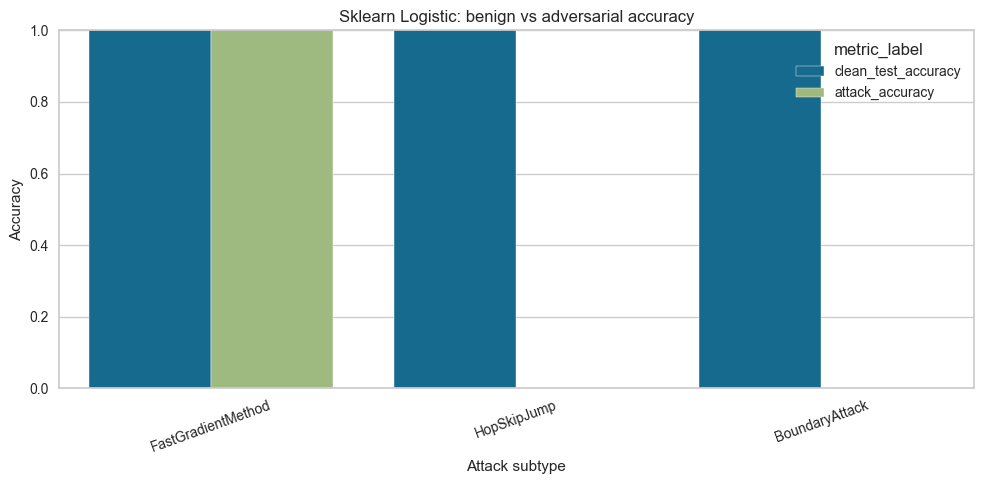

In [4]:
sklearn_evasion_specs = [
    {
        "attack_subtype": "FastGradientMethod",
        "attack_type": "art.attacks.evasion.FastGradientMethod",
        "attack_params": {"eps": 0.15, "eps_step": 0.05, "norm": "inf", "targeted": False, "minimal": False},
        "attack_size": 24,
    },
    {
        "attack_subtype": "HopSkipJump",
        "attack_type": "art.attacks.evasion.HopSkipJump",
        "attack_params": {"max_iter": 3, "init_eval": 4, "max_eval": 16, "init_size": 12, "norm": 2, "targeted": False, "verbose": False},
        "attack_size": 12,
    },
    {
        "attack_subtype": "BoundaryAttack",
        "attack_type": "art.attacks.evasion.BoundaryAttack",
        "attack_params": {"batch_size": 6, "targeted": False, "delta": 0.01, "epsilon": 0.01, "max_iter": 2, "num_trial": 5, "sample_size": 6, "init_size": 12, "min_epsilon": 0.0, "verbose": False},
        "attack_size": 12,
    },
]

sklearn_evasion_data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 220,
        "n_features": 10,
        "n_informative": 6,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "class_sep": 1.4,
        "random_state": SEED,
    },
    train_size=160,
    test_size=60,
    random_state=SEED,
    stratify=True,
    classifier=True,
)
sklearn_evasion_data()

sklearn_evasion_model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 300},
)
sklearn_evasion_model(sklearn_evasion_data)

sklearn_evasion_rows = []
for spec in sklearn_evasion_specs:
    attack = AttackConfig(
        attack_type=spec["attack_type"],
        attack_params=spec["attack_params"],
        attack_size=spec["attack_size"],
    )
    scores = attack(data=sklearn_evasion_data, model=sklearn_evasion_model)
    sklearn_evasion_rows.append(
        {
            "model_name": "sklearn_logistic",
            "attack_family": "evasion",
            "attack_subtype": spec["attack_subtype"],
            "clean_test_accuracy": float(scores["benign_accuracy"]),
            "attack_accuracy": float(scores["evasion_accuracy"]),
            **timing_payload(scores),
        }
    )

sklearn_evasion_df = pd.DataFrame(sklearn_evasion_rows)
display(sklearn_evasion_df)
plot_grouped_accuracy(sklearn_evasion_df, "Sklearn Logistic: benign vs adversarial accuracy")

sklearn_evasion_df.to_csv(ARTIFACT_DIR / "sklearn_evasion_results.csv", index=False)

## Poisoning: sklearn SVC

This section uses ART's `PoisoningAttackSVM` with a sklearn `SVC` victim. The comparison stays inside the poisoning score context and reports `benign_*` against `poisoned_*`.

,model_name,attack_family,attack_subtype,clean_accuracy,poisoned_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,sklearn_svc,poisoning,PoisoningAttackSVM,0.883333,0.866667,6.0,1.382761,0.001727,0.003895


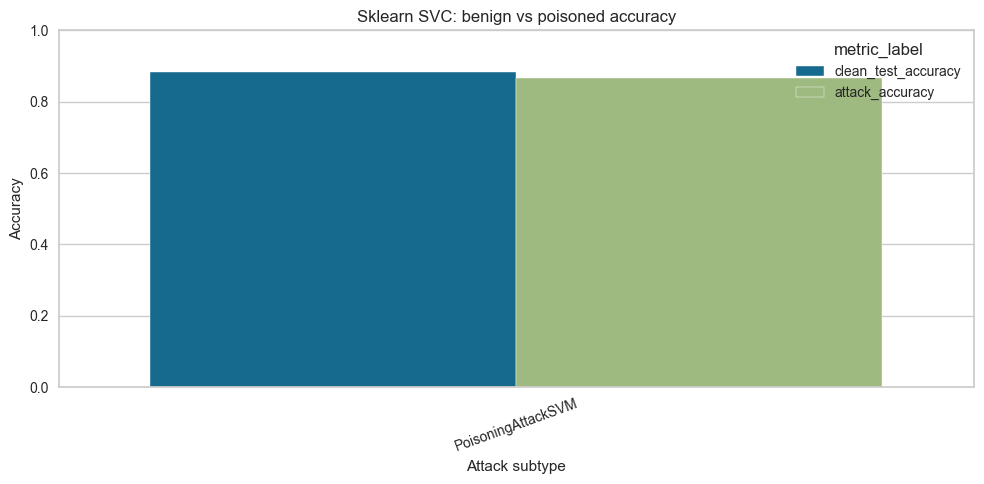

In [4]:
sklearn_poison_data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 180,
        "n_features": 8,
        "n_informative": 6,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "class_sep": 1.2,
        "random_state": SEED + 10,
    },
    train_size=120,
    test_size=60,
    random_state=SEED + 10,
    stratify=True,
    classifier=True,
)
sklearn_poison_data()

sklearn_poison_model = ModelConfig(
    model_type="sklearn.svm.SVC",
    classifier=True,
    model_params={"kernel": "linear", "probability": True, "C": 1.0},
)
sklearn_poison_model(sklearn_poison_data)

sklearn_poison_attack = AttackConfig(
    attack_type="art.attacks.poisoning.PoisoningAttackSVM",
    attack_params={"step": 0.05, "eps": 0.2, "max_iter": 2, "verbose": False},
    attack_size=6,
)
sklearn_poison_scores = sklearn_poison_attack(data=sklearn_poison_data, model=sklearn_poison_model)

sklearn_poison_df = pd.DataFrame(
    [
        {
            "model_name": "sklearn_svc",
            "attack_family": "poisoning",
            "attack_subtype": "PoisoningAttackSVM",
            "clean_accuracy": float(sklearn_poison_scores["benign_accuracy"]),
            "poisoned_accuracy": float(sklearn_poison_scores["poisoned_accuracy"]),
            **timing_payload(sklearn_poison_scores),
        }
    ]
)

display(sklearn_poison_df)
plot_grouped_accuracy(
    sklearn_poison_df.rename(columns={"clean_accuracy": "clean_test_accuracy", "poisoned_accuracy": "attack_accuracy"}),
    "Sklearn SVC: benign vs poisoned accuracy",
)

sklearn_poison_df.to_csv(ARTIFACT_DIR / "sklearn_poisoning_results.csv", index=False)

## Membership Inference

This section uses the membership-inference score namespace directly. The chart below compares membership-specific metrics only, so the bars stay within one scoring context.

,model_name,attack_family,attack_subtype,metric_name,metric_value
0,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_accuracy,0.33
1,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_precision,0.11
2,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_recall,0.33
3,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_f1,0.17


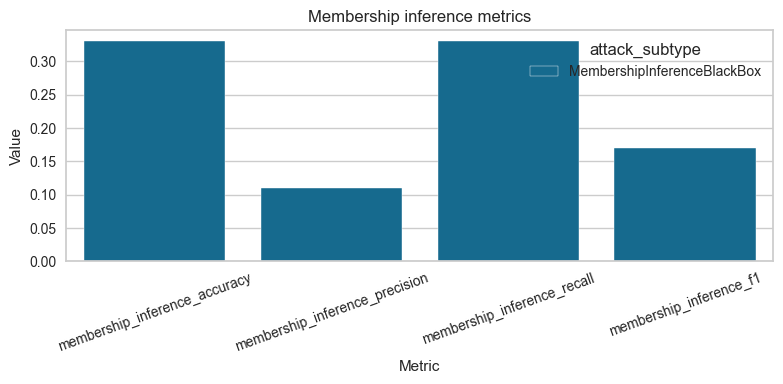

In [5]:
membership_data = make_sensitive_tabular_data()
membership_model = LogisticRegression(max_iter=300)
membership_model.fit(membership_data.X_train.values, membership_data.y_train.values)

membership_attack = AttackConfig(
    attack_type="art.attacks.inference.membership_inference.MembershipInferenceBlackBox",
    attack_params={},
    attack_size=60,
)
membership_scores = membership_attack(data=membership_data, model=membership_model)

membership_metric_df = pd.DataFrame(
    score_rows(
        membership_scores,
        prefix="membership_inference_",
        model_name="sklearn_logistic",
        attack_family="membership_inference",
        attack_subtype="MembershipInferenceBlackBox",
    )
)
display(membership_metric_df)
plot_metric_context(membership_metric_df, "Membership inference metrics")

membership_metric_df.to_csv(ARTIFACT_DIR / "membership_inference_metrics.csv", index=False)

## Attribute Inference

Attribute inference can score either classification or regression-style targets. Here the targeted attribute is continuous (`age`), so the notebook keeps the output in a regression-style table instead of forcing it into an accuracy chart.

In [6]:
attribute_data = make_sensitive_tabular_data(seed=SEED + 1)
attribute_model = LogisticRegression(max_iter=300)
attribute_model.fit(attribute_data.X_train.values, attribute_data.y_train.values)

attribute_attack = AttackConfig(
    attack_type="art.attacks.inference.attribute_inference.AttributeInferenceBlackBox",
    targeted_attribute=["age"],
    attack_params={
        "attack_model_type": "nn",
        "is_continuous": True,
        "scale_range": (18, 70),
        "nn_model_epochs": 10,
    },
    attack_size=70,
)
attribute_scores = attribute_attack(data=attribute_data, model=attribute_model)

attribute_metric_df = pd.DataFrame(
    score_rows(
        attribute_scores,
        prefix="inferred_age_",
        model_name="sklearn_logistic",
        attack_family="attribute_inference",
        attack_subtype="AttributeInferenceBlackBox",
    )
).sort_values("metric_name")

display(attribute_metric_df)
attribute_metric_df.to_csv(ARTIFACT_DIR / "attribute_inference_metrics.csv", index=False)

,model_name,attack_family,attack_subtype,metric_name,metric_value
1,sklearn_logistic,attribute_inference,AttributeInferenceBlackBox,inferred_age_mae,47.85
0,sklearn_logistic,attribute_inference,AttributeInferenceBlackBox,inferred_age_mse,2468.35
2,sklearn_logistic,attribute_inference,AttributeInferenceBlackBox,inferred_age_r2,-12.78


## Evasion: torch TinyNet

The torch section reuses the repo's TensorDataset path and a tiny neural classifier. It stays inside the same evasion score context as the sklearn section, so the charts are directly interpretable within the family.

,model_name,attack_family,attack_subtype,clean_test_accuracy,attack_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,torch_tinynet,evasion,FastGradientMethod,0.333333,0.5,12.0,0.090291,0.000108,0.001650
1,torch_tinynet,evasion,HopSkipJump,0.250000,0.2,8.0,0.005629,0.000086,0.001716
2,torch_tinynet,evasion,BoundaryAttack,0.250000,0.2,8.0,0.005517,0.000074,0.001706


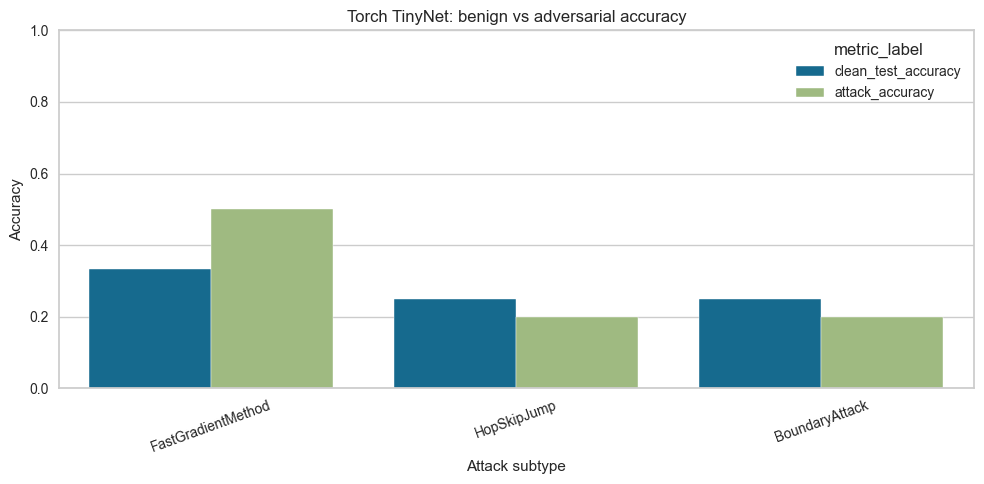

In [7]:
torch_evasion_specs = [
    {
        "attack_subtype": "FastGradientMethod",
        "attack_type": "art.attacks.evasion.FastGradientMethod",
        "attack_params": {"eps": 0.12, "eps_step": 0.04, "norm": "inf", "targeted": False, "minimal": False},
        "attack_size": 12,
    },
    {
        "attack_subtype": "HopSkipJump",
        "attack_type": "art.attacks.evasion.HopSkipJump",
        "attack_params": {"max_iter": 2, "init_eval": 4, "max_eval": 12, "init_size": 8, "norm": 2, "targeted": False, "verbose": False},
        "attack_size": 8,
    },
    {
        "attack_subtype": "BoundaryAttack",
        "attack_type": "art.attacks.evasion.BoundaryAttack",
        "attack_params": {"batch_size": 4, "targeted": False, "delta": 0.01, "epsilon": 0.01, "max_iter": 2, "num_trial": 4, "sample_size": 4, "init_size": 8, "min_epsilon": 0.0, "verbose": False},
        "attack_size": 8,
    },
]

torch_evasion_data = build_torch_tensor_data()
torch_evasion_model = PytorchModelConfig(
    model_type=TinyNet,
    model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
    classifier=True,
    fit_params={"nb_epochs": 3, "batch_size": 16},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.05},
)
torch_evasion_model(torch_evasion_data)

torch_evasion_rows = []
for spec in torch_evasion_specs:
    attack = PytorchAttackConfig(
        attack_type=spec["attack_type"],
        attack_params=spec["attack_params"],
        attack_size=spec["attack_size"],
    )
    scores = attack(data=torch_evasion_data, model=torch_evasion_model)
    torch_evasion_rows.append(
        {
            "model_name": "torch_tinynet",
            "attack_family": "evasion",
            "attack_subtype": spec["attack_subtype"],
            "clean_test_accuracy": float(scores["benign_accuracy"]),
            "attack_accuracy": float(scores["evasion_accuracy"]),
            **timing_payload(scores),
        }
    )

torch_evasion_df = pd.DataFrame(torch_evasion_rows)
display(torch_evasion_df)
plot_grouped_accuracy(torch_evasion_df, "Torch TinyNet: benign vs adversarial accuracy")

torch_evasion_df.to_csv(ARTIFACT_DIR / "torch_evasion_results.csv", index=False)

## Extraction: pretrained torch ResNet18

Extraction is only supported for neural-network ART classifiers. This section uses the existing `ResNet18` example model and runs a small `CopycatCNN` attack in its own `benign_*` vs `extracted_*` scoring context.

,model_name,attack_family,attack_subtype,clean_accuracy,extracted_accuracy,extraction_mode,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,torch_resnet18,extraction,CopycatCNN,0.166667,0.833333,test,4.0,1.141787,1.085256,0.003692


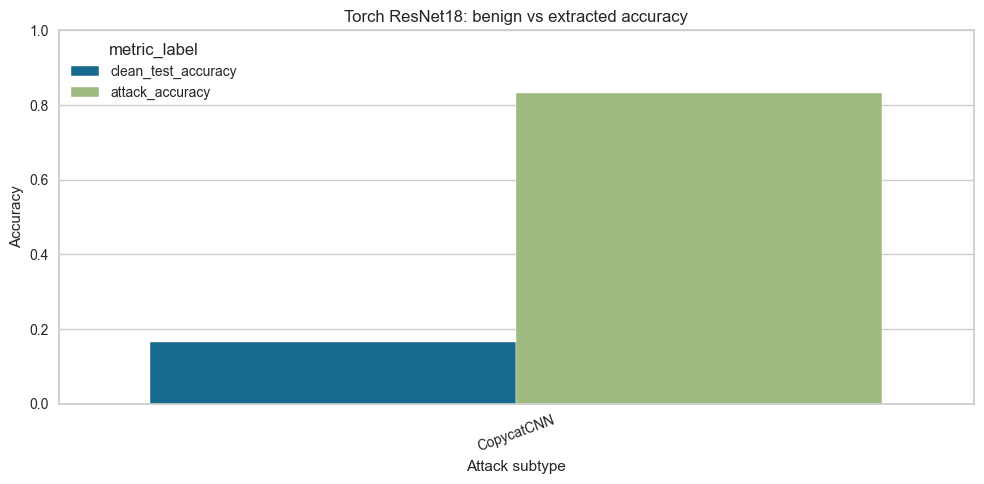

In [5]:
from torch_example import ResNet18

torch_extraction_data = build_torch_image_data(seed=SEED + 20)
torch_extraction_model = PytorchModelConfig(
    model_type="torch_example.ResNet18",
    model_params={"num_channels": 3, "num_classes": 2},
    classifier=True,
    fit_params={"nb_epochs": 1, "batch_size": 2},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.001},
)
torch_extraction_model(torch_extraction_data)

torch_extraction_attack = AttackConfig(
    attack_type="art.attacks.extraction.CopycatCNN",
    attack_params={
        "batch_size_fit": 2,
        "batch_size_query": 2,
        "nb_epochs": 1,
        "nb_stolen": 4,
        "use_probability": False,
    },
    attack_size=4,
)
torch_extraction_scores = torch_extraction_attack(
    data=torch_extraction_data,
    model=torch_extraction_model,
)

torch_extraction_df = pd.DataFrame(
    [
        {
            "model_name": "torch_resnet18",
            "attack_family": "extraction",
            "attack_subtype": "CopycatCNN",
            "clean_accuracy": float(torch_extraction_scores["benign_accuracy"]),
            "extracted_accuracy": float(torch_extraction_scores["extracted_accuracy"]),
            "extraction_mode": torch_extraction_scores.get("extraction_mode"),
            **timing_payload(torch_extraction_scores),
        }
    ]
)

display(torch_extraction_df)
plot_grouped_accuracy(
    torch_extraction_df.rename(columns={"clean_accuracy": "clean_test_accuracy", "extracted_accuracy": "attack_accuracy"}),
    "Torch ResNet18: benign vs extracted accuracy",
)

torch_extraction_df.to_csv(ARTIFACT_DIR / "torch_extraction_results.csv", index=False)

## Summary

The notebook ends by keeping one summary table of implemented sections and their primary metrics. This is intentionally descriptive rather than comparative across families.

In [6]:
implemented_sections = pd.DataFrame(
    [
        {
            "attack_family": "evasion",
            "model_tracks": "sklearn logistic, torch TinyNet",
            "subtypes": "FastGradientMethod, HopSkipJump, BoundaryAttack",
            "primary_metrics": "benign_accuracy, evasion_accuracy",
        },
        {
            "attack_family": "membership_inference",
            "model_tracks": "sklearn logistic",
            "subtypes": "MembershipInferenceBlackBox",
            "primary_metrics": "membership_inference_accuracy, precision, recall, f1",
        },
        {
            "attack_family": "attribute_inference",
            "model_tracks": "sklearn logistic",
            "subtypes": "AttributeInferenceBlackBox",
            "primary_metrics": "inferred_age_mse, inferred_age_mae, inferred_age_r2",
        },
        {
            "attack_family": "poisoning",
            "model_tracks": "sklearn SVC",
            "subtypes": "PoisoningAttackSVM",
            "primary_metrics": "benign_accuracy, poisoned_accuracy",
        },
        {
            "attack_family": "extraction",
            "model_tracks": "pretrained torch ResNet18",
            "subtypes": "CopycatCNN",
            "primary_metrics": "benign_accuracy, extracted_accuracy",
        },
    ]
)

display(implemented_sections)

implemented_sections.to_csv(ARTIFACT_DIR / "implemented_sections.csv", index=False)

,attack_family,model_tracks,subtypes,primary_metrics
0,evasion,"sklearn logistic, torch TinyNet","FastGradientMethod, HopSkipJump, BoundaryAttack","benign_accuracy, evasion_accuracy"
1,membership_inference,sklearn logistic,MembershipInferenceBlackBox,"membership_inference_accuracy, precision, reca..."
2,attribute_inference,sklearn logistic,AttributeInferenceBlackBox,"inferred_age_mse, inferred_age_mae, inferred_a..."
3,poisoning,sklearn SVC,PoisoningAttackSVM,"benign_accuracy, poisoned_accuracy"
4,extraction,pretrained torch ResNet18,CopycatCNN,"benign_accuracy, extracted_accuracy"
